In [1]:
import torch
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
import torch

print("Torch Version:", torch.__version__)
print("CUDA Version:", torch.version.cuda)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch Version: 2.11.0+cu128
CUDA Version: 12.8
CUDA Available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [4]:
transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor()
])

In [5]:
from torch.utils.data import random_split
from pathlib import Path

ROOT= Path.cwd().parent

full_train_dataset = ImageFolder(ROOT / "data" / "CIFAKE" / "train",transform=transform)

train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

In [6]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,num_workers=4,pin_memory=True,persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False,num_workers=4,pin_memory=True,persistent_workers=True)

test_dataset = ImageFolder(ROOT / "data" / "CIFAKE" / "test",
                        transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [7]:
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))
print("Val size:", len(val_dataset))

print("Classes:", full_train_dataset.classes)

Train size: 90000
Test size: 20000
Val size: 10000
Classes: ['FAKE', 'REAL']


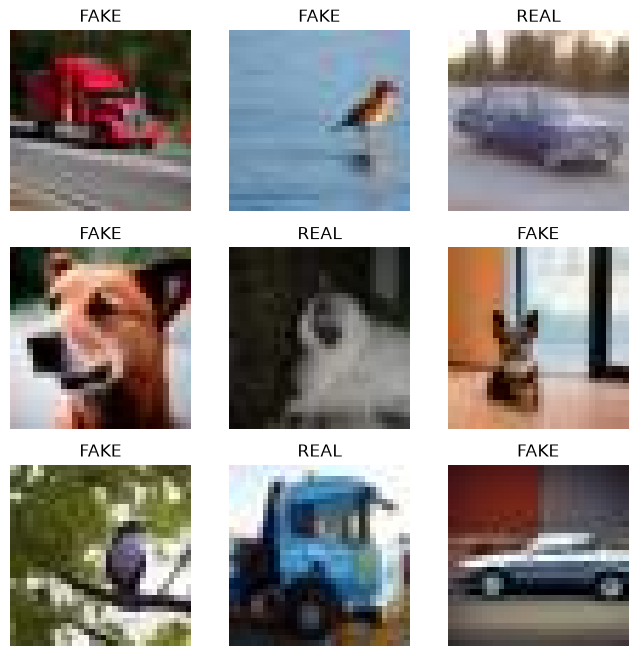

In [8]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title(full_train_dataset.classes[labels[i]])
    plt.axis("off")

plt.show()

In [10]:
import torch.nn as nn

class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(64*8*8, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [13]:
model = CNN()
print(model)

CNN(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=4096, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device}: {torch.cuda.get_device_name(0)}")

model.to(device)

Using cuda: NVIDIA GeForce RTX 3050 Laptop GPU


CNN(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=4096, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=2, bias=True)
  )
)

In [15]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print(device)

cuda


In [16]:
criterion = nn.CrossEntropyLoss()

import torch.optim as optim
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [18]:
import torch
import matplotlib.pyplot as plt

print(f"Training on: {next(model.parameters()).device}")

epochs = 5

train_loss_history = []
val_loss_history = []
val_acc_history = []

best_val_loss = float("inf")

for epoch in range(epochs):
    
    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    
    model.eval()

    running_val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_accuracy = 100 * correct / total

    val_loss_history.append(avg_val_loss)
    val_acc_history.append(val_accuracy)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_model.pth")

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2f}%"
    )

print("\nTraining Finished!")

Training on: cuda:0
Epoch [1/5] | Train Loss: 0.2950 | Val Loss: 0.1943 | Val Acc: 92.21%
Epoch [2/5] | Train Loss: 0.1892 | Val Loss: 0.1716 | Val Acc: 93.20%
Epoch [3/5] | Train Loss: 0.1608 | Val Loss: 0.1508 | Val Acc: 94.04%
Epoch [4/5] | Train Loss: 0.1446 | Val Loss: 0.1552 | Val Acc: 93.72%
Epoch [5/5] | Train Loss: 0.1284 | Val Loss: 0.1406 | Val Acc: 94.39%

Training Finished!


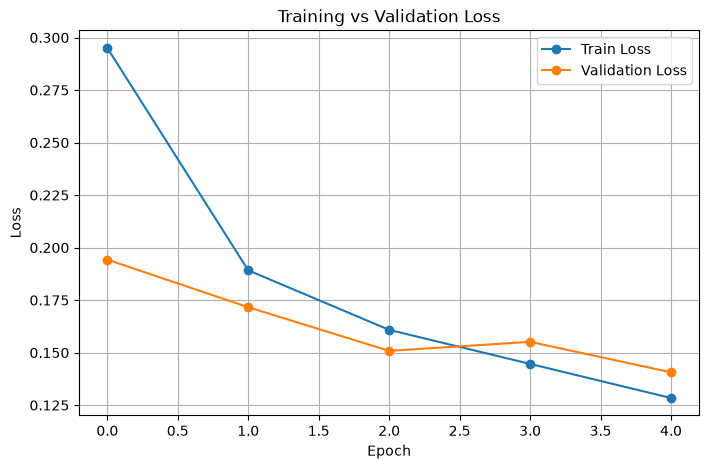

In [19]:
plt.figure(figsize=(8,5))

plt.plot(train_loss_history, label="Train Loss", marker='o')
plt.plot(val_loss_history, label="Validation Loss", marker='o')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

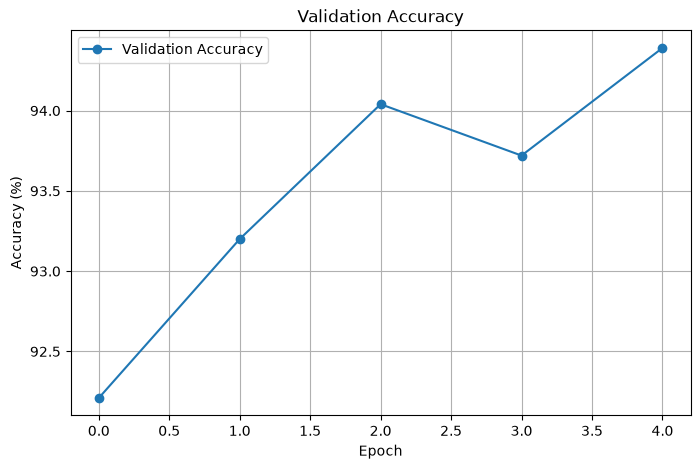

In [20]:
plt.figure(figsize=(8,5))

plt.plot(val_acc_history, label="Validation Accuracy", marker='o')

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [21]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

CNN(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=4096, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=2, bias=True)
  )
)

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, dim=1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nConfusion Matrix")
print(cm)

print("\nClassification Report")
print(classification_report(all_labels, all_preds))

Accuracy : 0.9405
Precision: 0.9532
Recall   : 0.9265
F1 Score : 0.9397

Confusion Matrix
[[9545  455]
 [ 735 9265]]

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.95      0.94     10000
           1       0.95      0.93      0.94     10000

    accuracy                           0.94     20000
   macro avg       0.94      0.94      0.94     20000
weighted avg       0.94      0.94      0.94     20000

